# Examen Primera Convocatoria, Franja Horaria Mañana

In [11]:
# Your imports HERE !!!!
import numpy as np
import pandas as pd
import numpy.linalg as linalg
import math
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## 01 - 1.5pt
- Utilizando Matplotlib y Seaborn, crea un gráfico de dispersión (scatter plot) que muestre la relación entre las columnas ‘A’ y ‘B’ del siguiente DataFrame. Además, ajusta una línea de regresión a los datos.

In [2]:
# Data
df = pd.DataFrame({'A': [1, 2, 3, 4, 5], 'B': [5.4, 4.1, 2.8, 1.9, 0.7]})

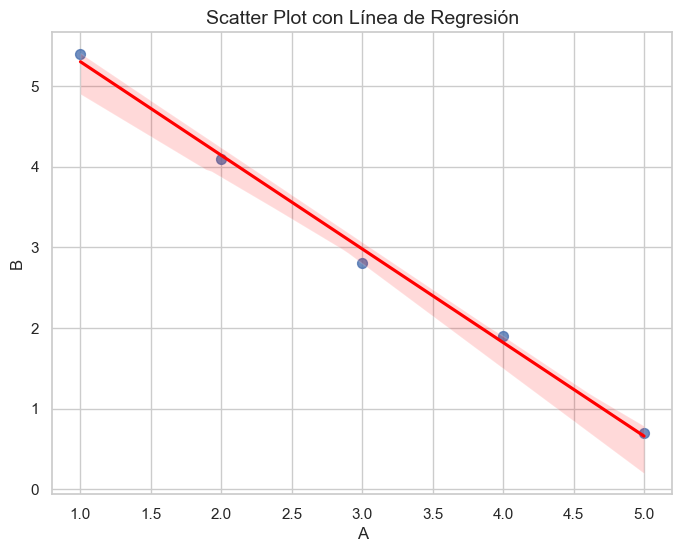

In [4]:
# Your solution HERE !!!!
# Configurar el estilo de Seaborn
# sns.set(style="whitegrid")

# Crear el scatter plot con línea de regresión
plt.figure(figsize=(8, 6))
sns.regplot(x='A', y='B', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Scatter Plot con Línea de Regresión', fontsize=14)
plt.xlabel('A', fontsize=12)
plt.ylabel('B', fontsize=12)
plt.show()


## 02 - 1.5pt
- Escribe una función que reciba un DataFrame, le agregue una nueva columna llamada ‘Promedio’ que sea el promedio de sus columnas Luego, filtre las filas donde el valor de ‘Promedio’ sea mayor que 5 y lo ordene por la columna ‘Promedio’ en orden descendente

In [9]:
# Your solution HERE !!!!
def func_mean(df):
    # Agregar columna 'Promedio' con el promedio de las columnas existentes
    df['Promedio'] = df.mean(axis=1)
    # Filtrar filas donde 'Promedio' > 5
    filtered_df = df[df['Promedio'] > 5]
    # Ordenar por 'Promedio' en orden descendente
    result = filtered_df.sort_values(by='Promedio', ascending=False).reset_index(drop=True)
    return result

In [10]:
# Test Use Case
source_dataframe = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 7, 6], 'C': [7, 12, 9]})
expected_dataframe = pd.DataFrame({'A': [2, 3], 'B': [7, 6], 'C': [12, 9], 'Promedio':[7.0, 6.0]})

output = func_mean(source_dataframe) # This calls your function named func_mean

display(expected_dataframe)
display(output)

assert(expected_dataframe.equals(output)) # This will fail if the dataframe is wrong

,A,B,C,Promedio
0,2,7,12,7.0
1,3,6,9,6.0


,A,B,C,Promedio
0,2,7,12,7.0
1,3,6,9,6.0


## 03 - 1.5pt
- Escribe una función que cada vez que se le invoque devuelva el factorial del siguiente número entero, empezando por 1, hasta cualquier número infinito

In [14]:
# Your solution HERE !!!!
def fact_gen():
    n = 1
    while True:
        yield math.factorial(n)
        n += 1

In [15]:
# Test Use Case
expected_output = [1, 2, 6, 24, 120, 720, 5040, 40320]

g = fact_gen()  # This calls your function named fact_gen
output = [next(g) for n in range(len(expected_output))]

display(expected_output)
display(output)

assert(expected_output == output) # This will fail if the list is wrong

[1, 2, 6, 24, 120, 720, 5040, 40320]

[1, 2, 6, 24, 120, 720, 5040, 40320]

## 04 - 1.5pt
- Crear una función que reciba un array de NumPy y que reemplace todos los números primos por sus raices cuadradas
- Primo es aquel número natural mayor que 1, que solo es divisible por 1 y por si mismo

In [30]:
# Your solution HERE !!!!
def prime_per_sqrt(arr):

    arr = arr.astype(np.float64)
    # Iterar sobre cada elemento del array
    for i in range(arr.shape[0]):  # Recorrer las filas
        for j in range(arr.shape[1]):  # Recorrer las columnas
            num = arr[i, j]
            
            # Verificar si el número es mayor que 1 (solo los números mayores a 1 pueden ser primos)
            if num > 1:
                # Verificar si el número es primo
                es_primo = True
                for k in range(2, int(math.sqrt(num)) + 1):
                    if num % k == 0:
                        es_primo = False
                        break
                
                # Si es primo, reemplazar por su raíz cuadrada
                if es_primo:
                    # Asegurarse de que el valor se almacene como flotante con dos decimales
                    arr[i, j] = round(math.sqrt(num), 2)
    
    return arr

In [31]:
# Test Use Case
source_array = np.array([[20, 17, 33, 11], [3, 25, 5, 49], [18, 28, 32, 2], [9, 1, 23, 40]])
expected_output = np.array([[20, 4.12, 33, 3.31], [1.73, 25, 2.23, 49], [18, 28, 32, 1.41], [9, 1, 4.79, 40]])

output = prime_per_sqrt(source_array) # This calls your function named prime_per_sqrt

display(expected_output)
display(output)

assert(np.allclose(output, expected_output, atol = 0.01)) # This will fail if the array is wrong

array([[20.  ,  4.12, 33.  ,  3.31],
       [ 1.73, 25.  ,  2.23, 49.  ],
       [18.  , 28.  , 32.  ,  1.41],
       [ 9.  ,  1.  ,  4.79, 40.  ]])

array([[20.  ,  4.12, 33.  ,  3.32],
       [ 1.73, 25.  ,  2.24, 49.  ],
       [18.  , 28.  , 32.  ,  1.41],
       [ 9.  ,  1.  ,  4.8 , 40.  ]])

## 05 - 4pt

El conjunto de datos "estaciones_bici.csv" (fichero disponible adjunto al notebook) proviene de una descarga de datos del servicio web de la empresa municipal Valenbici, dedicada al alquiler de bicicletas en Valencia.

Los datos recabados de este servicio web son de mediciones cada 10 minutos de las estaciones:

https://valencia.opendatasoft.com/explore/dataset/valenbisi-disponibilitat-valenbisi-dsiponibilidad/information/

Cada estación está compuesta por un número variable de bornetas (total) donde se pueden anclar las bicicletas. Los datos obtenidos de cada estación (registros) refleja el número de bornetas libres (free) y el número de bicicletas disponibles (available).

#### Columnas para trabajar:
- station: id de la estación
- total: número total de bornetas
- updated: timestamp del estado en de bicis en la estación
- available: número de bicis disponibles

#### Preguntas
1. Carga de datos de csv (estaciones_bici.csv) en un DataFrame, descripción de los datos
2. ¿Cuál es el rango temporal del dataset? Obtención del número de estaciones que tienen un total de 25 bornetas, y cuales son
3. Número de estación con la media más baja de bicis disponibles
4. Realizar el histograma de bicis disponibles de la estación del punto anterior
5. Realizar gráfica con  la línea temporal de bicis disponibles de la estación del punto anterior. Pista, es necesario cambiar el índice a uno tipo fecha

In [ ]:
# Your solution HERE !!!!

#### 1. Carga de datos de csv (estaciones_bici.csv) en un DataFrame, descripción de los datos

In [36]:
# Cargar el archivo CSV en un DataFrame
df = pd.read_csv('estaciones_bici.csv',delimiter = "|")

# Mostrar las primeras filas del DataFrame para una vista previa
display(df)

# # Obtener una descripción general de los datos (tipos de datos, valores únicos, etc.)
# print(df.info())

# # Obtener estadísticas descriptivas de las columnas numéricas
# print(df.describe())

,Unnamed: 0,updated,address,number,available,lat,lon,total,open,free
0,72967,2023-05-04 16:20:06,Peris y Valero - Cuba,39,5,39.457854,-0.373931,19,T,14
1,94523,2023-05-04 16:20:06,Pintor Luis Arcas - Inst. Obrero Valenciano,46,4,39.455509,-0.358787,20,T,16
2,193949,2023-05-04 16:20:06,Alfonso el Magnánimo - Nave,13,15,39.472062,-0.370874,24,T,9
3,30541,2023-05-04 16:20:06,Angel Guimerá - Juan Llorens,22,4,39.469787,-0.388353,15,T,11
4,63530,2023-05-04 16:20:06,Fernando el Católico - Cuenca,24,7,39.469077,-0.384027,20,T,11
...,...,...,...,...,...,...,...,...,...,...
222175,183443,2023-05-10 16:00:07,Tres Cruces - Segunda República Española,249,5,39.459506,-0.402740,15,T,10
222176,163288,2023-05-10 16:00:07,"Plaza Salvador Soria, 8",257,7,39.445251,-0.389104,20,T,13
222177,123741,2023-05-10 16:00:07,Pio IX - Músico Cabanilles,259,17,39.445460,-0.393015,20,T,2
222178,29724,2023-05-10 16:00:07,Canal de Navarrés - Maestro Rodrigo,266,6,39.490289,-0.406371,18,T,12


#### 2. ¿Cuál es el rango temporal del dataset? Obtención del número de estaciones que tienen un total de 25 bornetas, y cuales son

In [39]:
start_date = df['updated'].min()
end_date = df['updated'].max()

print(f"El rango temporal del dataset de polución es desde la fecha: {start_date} a la fecha: {end_date}")

# Filtrar las estaciones con 25 bornetas
estaciones_25_bornetas = df[df['total'] == 25]

# Obtener el número de estaciones
num_estaciones_25 = estaciones_25_bornetas.shape[0]

# Mostrar las estaciones
# print(estaciones_25_bornetas[['address', 'total']])

print(f"Hay {num_estaciones_25} estaciones con un total de 25 bornetas.")

# EXTRA
# # Agrupar los datos por fecha y contar el número de estaciones con 25 bornetas
# estaciones_por_dia = df.groupby('updated')['total'].apply(lambda x: (x == 25).sum()).reset_index(name='count_25')

# # Crear un gráfico de líneas para visualizar la evolución
# estaciones_por_dia.plot(x='updated', y='count_25', kind='line')

El rango temporal del dataset de polución es desde la fecha: 2023-05-04 16:20:06 a la fecha: 2023-05-10 16:00:07
Hay 15295 estaciones con un total de 25 bornetas.


#### 3. Número de estación con la media más baja de bicis disponibles

In [48]:
mean_co = df.groupby('number')['available'].mean()
mean_min_est = mean_co.idxmin()

# mean_co = df.groupby('number')['available'].mean().reset_index()
# mean_min_est = mean_co.loc[mean_co['available'].idxmin()]

print(f"La estación con la media más baja de bicis disponibles es: ", mean_min_est)

La estación con la media más baja de bicis disponibles es:  269


#### 4. Realizar el histograma de bicis disponibles de la estación del punto anterior

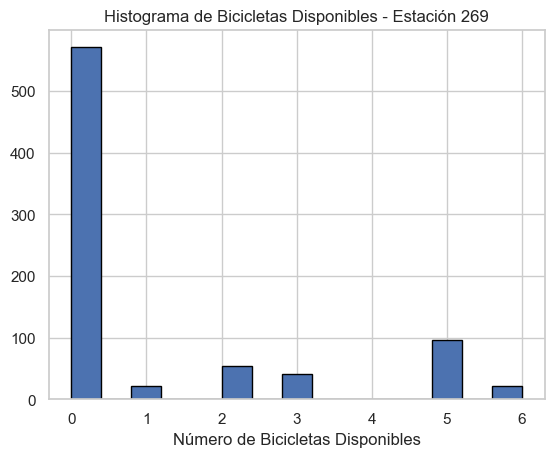

In [51]:
# Filtrar los datos para la estación con la media más baja
estacion_menos_bicis = df[df['number'] == mean_min_est]

# Crear el histograma
plt.hist(estacion_menos_bicis['available'], bins=15, edgecolor='black')  # Ajusta el número de bins según tus datos
plt.title(f'Histograma de Bicicletas Disponibles - Estación {mean_min_est}')
plt.xlabel('Número de Bicicletas Disponibles')
# plt.ylabel('Frecuencia')
plt.show()

#### 5.Realizar gráfica con la línea temporal de bicis disponibles de la estación del punto anterior. Pista, es necesario cambiar el índice a uno tipo fecha

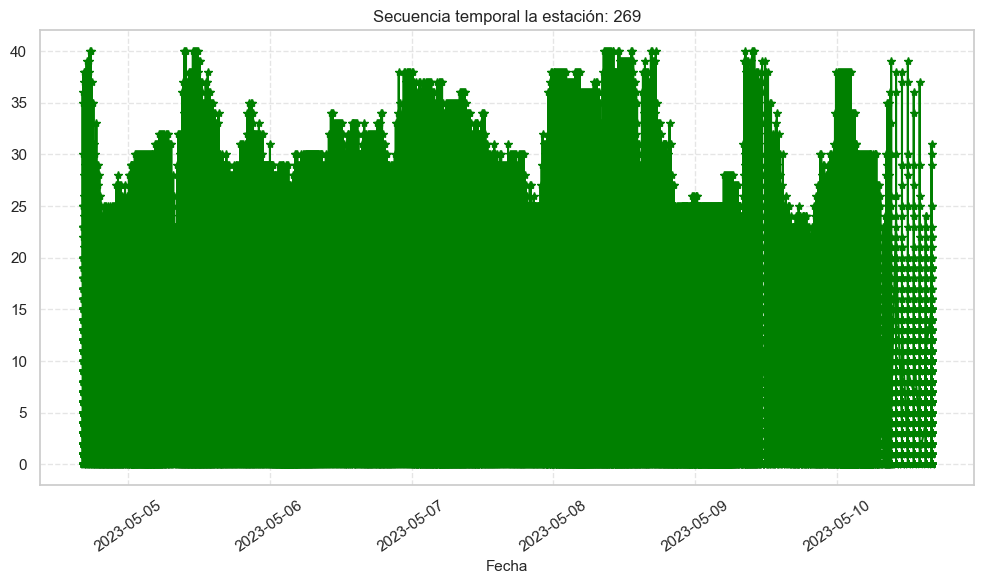

In [58]:
# convertimos la columna fecha_carga a tipo datetime
df.loc[:, 'updated'] = pd.to_datetime(df['updated'])


plt.figure(figsize=(10, 6))
plt.plot(df['updated'], df['available'], marker='*', color='green')
plt.title(f"Secuencia temporal la estación: {mean_min_est}", fontsize=12)
plt.xlabel("Fecha", fontsize=11)
# plt.ylabel("Medición de ozono", fontsize=11)
plt.grid(axis='both', linestyle='--', alpha=0.5)
# plt.legend(fontsize=10)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()